In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
!pip install -q ucimlrepo

In [4]:
from ucimlrepo import fetch_ucirepo

# Fetch UCI Heart Disease dataset
heart_disease = fetch_ucirepo(id=45)

X = heart_disease.data.features
y = heart_disease.data.targets

print("Dataset loaded successfully!")
print("Features shape:", X.shape)
print("Target shape:", y.shape)

X.head()

Dataset loaded successfully!
Features shape: (303, 13)
Target shape: (303, 1)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0


In [5]:
print("Feature columns:")
print(X.columns.tolist())

print("\nTarget column:")
print(y.columns.tolist())

print("\nDataset information:")
print(X.info())

Feature columns:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

Target column:
['num']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
dtypes: float64(3), int64(10)
memory usage: 30.9 KB
None


In [6]:
# Combine features and target into one DataFrame

df = pd.concat([X, y], axis=1)

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

Dataset shape: (303, 14)

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [7]:
# Check target distribution

print("Target value counts:")
print(df['num'].value_counts())

Target value counts:
num
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64


In [8]:
# Check missing values

print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
num         0
dtype: int64


In [9]:
# Convert target into binary classification
# 0 = No Heart Disease
# 1, 2, 3, 4 = Heart Disease

df['target'] = (df['num'] > 0).astype(int)

# Remove the original target column
df = df.drop('num', axis=1)

print("Target converted successfully!")
print("\nTarget distribution:")
print(df['target'].value_counts())

print("\nMissing values before handling:")
print(df.isnull().sum())

Target converted successfully!

Target distribution:
target
0    164
1    139
Name: count, dtype: int64

Missing values before handling:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


In [10]:
# Handle missing values using median

df = df.fillna(df.median(numeric_only=True))

print("Missing values handled successfully!")
print("\nMissing values after handling:")
print(df.isnull().sum())

Missing values handled successfully!

Missing values after handling:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [11]:
print("Final dataset shape:", df.shape)

display(df.head())

Final dataset shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


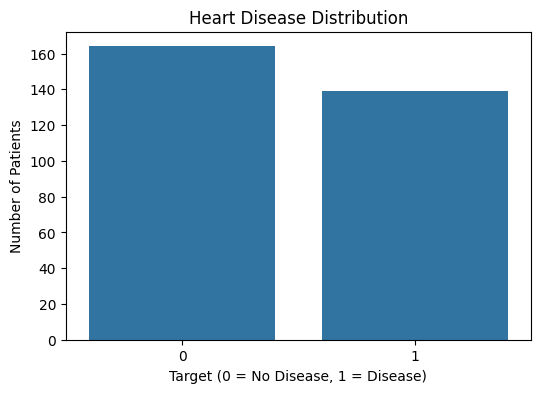

In [12]:
plt.figure(figsize=(6, 4))

sns.countplot(x='target', data=df)

plt.title("Heart Disease Distribution")
plt.xlabel("Target (0 = No Disease, 1 = Disease)")
plt.ylabel("Number of Patients")
plt.show()

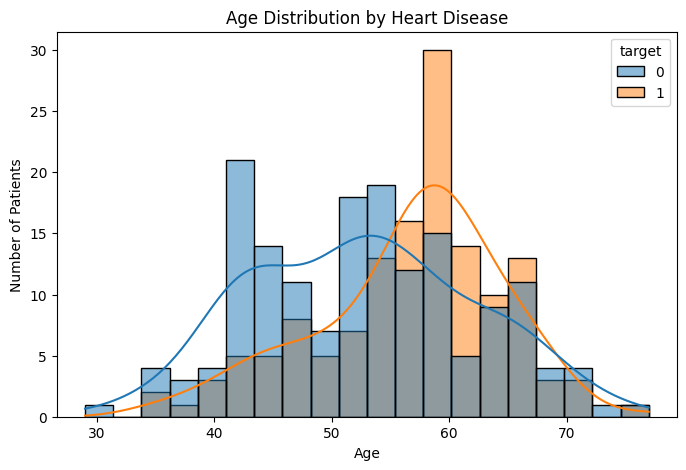

In [13]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x='age',
    hue='target',
    bins=20,
    kde=True
)

plt.title("Age Distribution by Heart Disease")
plt.xlabel("Age")
plt.ylabel("Number of Patients")
plt.show()

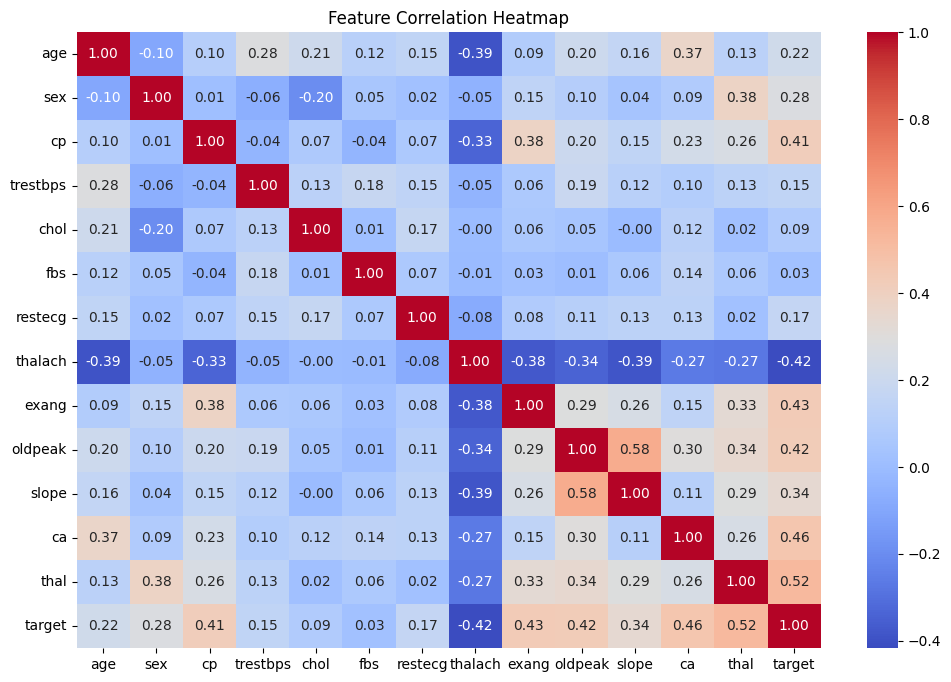

In [14]:
plt.figure(figsize=(12, 8))

correlation = df.corr()

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")
plt.show()

In [15]:
# Separate features and target

X = df.drop('target', axis=1)
y = df['target']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (303, 13)
Target shape: (303,)


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 242
Testing samples: 61


In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")
print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)

Feature scaling completed!
Scaled training shape: (242, 13)
Scaled testing shape: (61, 13)


In [18]:
from sklearn.linear_model import LogisticRegression

# Create the model
logistic_model = LogisticRegression(max_iter=1000)

# Train the model
logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [19]:
# Predict on test data

y_pred_lr = logistic_model.predict(X_test_scaled)

print("Predictions generated successfully!")
print("First 10 predictions:", y_pred_lr[:10])
print("First 10 actual values:", y_test.values[:10])

Predictions generated successfully!
First 10 predictions: [0 1 0 0 1 0 0 0 1 0]
First 10 actual values: [0 0 0 0 0 0 0 0 1 0]


In [20]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print("Logistic Regression Results")
print("--------------------------------")
print(f"Accuracy  : {accuracy_lr:.4f}")
print(f"Precision : {precision_lr:.4f}")
print(f"Recall    : {recall_lr:.4f}")
print(f"F1-Score  : {f1_lr:.4f}")

Logistic Regression Results
--------------------------------
Accuracy  : 0.8689
Precision : 0.8125
Recall    : 0.9286
F1-Score  : 0.8667


In [21]:
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=["No Heart Disease", "Heart Disease"]
    )
)


Classification Report:
                  precision    recall  f1-score   support

No Heart Disease       0.93      0.82      0.87        33
   Heart Disease       0.81      0.93      0.87        28

        accuracy                           0.87        61
       macro avg       0.87      0.87      0.87        61
    weighted avg       0.88      0.87      0.87        61



In [22]:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [23]:
# Predict on test data

y_pred_rf = random_forest_model.predict(X_test)

print("Predictions generated successfully!")
print("First 10 predictions:", y_pred_rf[:10])
print("First 10 actual values:", y_test.values[:10])

Predictions generated successfully!
First 10 predictions: [0 1 0 0 0 0 0 0 1 0]
First 10 actual values: [0 0 0 0 0 0 0 0 1 0]


In [24]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Random Forest Results")
print("--------------------------------")
print(f"Accuracy  : {accuracy_rf:.4f}")
print(f"Precision : {precision_rf:.4f}")
print(f"Recall    : {recall_rf:.4f}")
print(f"F1-Score : {f1_rf:.4f}")

Random Forest Results
--------------------------------
Accuracy  : 0.8852
Precision : 0.8387
Recall    : 0.9286
F1-Score : 0.8814


In [25]:
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=["No Heart Disease", "Heart Disease"]
    )
)


Classification Report:
                  precision    recall  f1-score   support

No Heart Disease       0.93      0.85      0.89        33
   Heart Disease       0.84      0.93      0.88        28

        accuracy                           0.89        61
       macro avg       0.89      0.89      0.89        61
    weighted avg       0.89      0.89      0.89        61



In [26]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [accuracy_lr, accuracy_rf],
    "Precision": [precision_lr, precision_rf],
    "Recall": [recall_lr, recall_rf],
    "F1-Score": [f1_lr, f1_rf]
})

display(results)

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.868852,0.81250,0.928571,0.866667
1,Random Forest,0.885246,0.83871,0.928571,0.881356


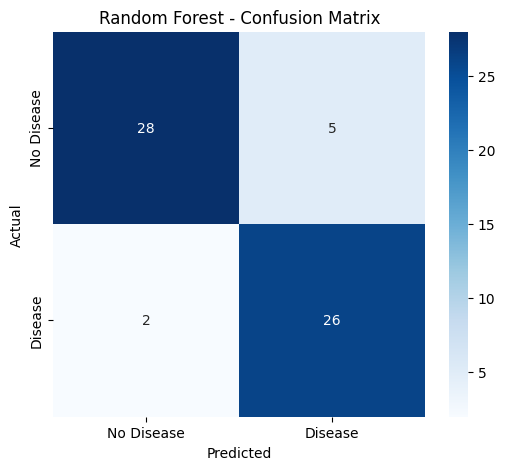

In [27]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Disease', 'Disease'],
    yticklabels=['No Disease', 'Disease']
)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [28]:
from sklearn.metrics import roc_auc_score, roc_curve

# Probability predictions
y_prob_lr = logistic_model.predict_proba(X_test_scaled)[:, 1]
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

# ROC-AUC scores
roc_auc_lr = roc_auc_score(y_test, y_prob_lr)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("ROC-AUC Results")
print("--------------------------------")
print(f"Logistic Regression: {roc_auc_lr:.4f}")
print(f"Random Forest      : {roc_auc_rf:.4f}")

ROC-AUC Results
--------------------------------
Logistic Regression: 0.9513
Random Forest      : 0.9518


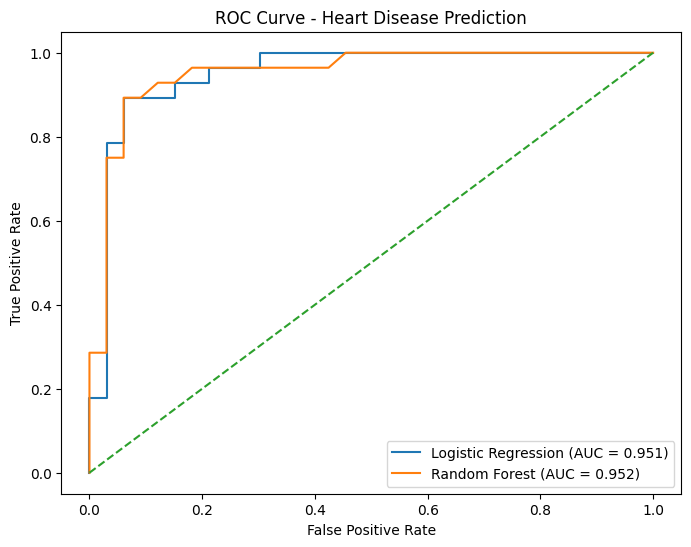

In [29]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression (AUC = {roc_auc_lr:.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {roc_auc_rf:.3f})"
)

plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Heart Disease Prediction")
plt.legend()
plt.show()

In [30]:
importance = pd.Series(
    random_forest_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Feature Importance:")
display(importance)

Feature Importance:


,0
thalach,0.135404
cp,0.127163
thal,0.122940
ca,0.100811
age,0.091327
oldpeak,0.089358
chol,0.088681
trestbps,0.080716
exang,0.050730
slope,0.046626


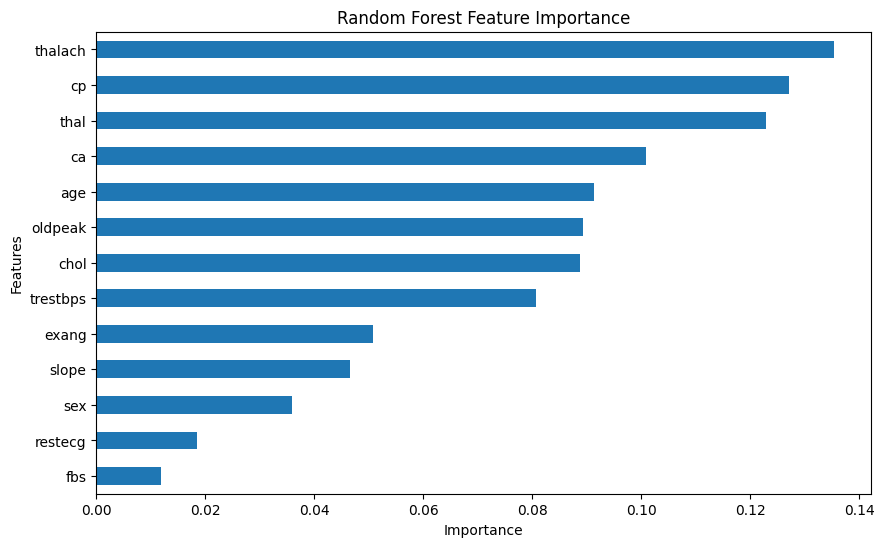

In [31]:
plt.figure(figsize=(10, 6))

importance.sort_values().plot(kind='barh')

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()

In [32]:
final_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [accuracy_lr, accuracy_rf],
    "Precision": [precision_lr, precision_rf],
    "Recall": [recall_lr, recall_rf],
    "F1-Score": [f1_lr, f1_rf],
    "ROC-AUC": [roc_auc_lr, roc_auc_rf]
})

display(final_results.round(4))

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8689,0.8125,0.9286,0.8667,0.9513
1,Random Forest,0.8852,0.8387,0.9286,0.8814,0.9518


In [33]:
best_model = (
    "Random Forest"
    if f1_rf >= f1_lr
    else "Logistic Regression"
)

print("Best model based on F1-Score:", best_model)

Best model based on F1-Score: Random Forest


In [34]:
import joblib

# Save the Random Forest model
joblib.dump(random_forest_model, "heart_disease_prediction_model.pkl")

# Save the scaler
joblib.dump(scaler, "scaler.pkl")

print("Model saved successfully!")
print("Scaler saved successfully!")

Model saved successfully!
Scaler saved successfully!


In [35]:
import os

print("Saved files:")
print(os.listdir())

Saved files:
['.config', 'heart_disease_prediction_model.pkl', 'scaler.pkl', 'sample_data']


In [36]:
def predict_heart_disease(patient_data):
    """
    Predict heart disease class using the trained Random Forest model.

    Note: This is an educational ML prediction and not a medical diagnosis.
    """

    patient_df = pd.DataFrame(
        [patient_data],
        columns=X.columns
    )

    prediction = random_forest_model.predict(patient_df)[0]
    probability = random_forest_model.predict_proba(patient_df)[0][1]

    if prediction == 1:
        result = "Higher predicted risk of heart disease"
    else:
        result = "Lower predicted risk of heart disease"

    print("Model Prediction:", result)
    print(f"Predicted Probability: {probability:.2%}")

    return prediction

In [37]:
sample_patient = X_test.iloc[0].tolist()

print("Sample patient data:")
print(sample_patient)

print("\nPrediction:")
predict_heart_disease(sample_patient)

Sample patient data:
[59.0, 1.0, 4.0, 138.0, 271.0, 0.0, 2.0, 182.0, 0.0, 0.0, 1.0, 0.0, 3.0]

Prediction:
Model Prediction: Lower predicted risk of heart disease
Predicted Probability: 24.00%


np.int64(0)

In [38]:
id="p6r731"
def predict_custom_patient():
    print("Enter Patient Information")
    print("--------------------------")

    age = float(input("Age: "))
    sex = float(input("Sex (1 = Male, 0 = Female): "))
    cp = float(input("Chest Pain Type (0-3): "))
    trestbps = float(input("Resting Blood Pressure: "))
    chol = float(input("Cholesterol: "))
    fbs = float(input("Fasting Blood Sugar > 120 (1 = Yes, 0 = No): "))
    restecg = float(input("Resting ECG (0-2): "))
    thalach = float(input("Maximum Heart Rate Achieved: "))
    exang = float(input("Exercise Induced Angina (1 = Yes, 0 = No): "))
    oldpeak = float(input("ST Depression (oldpeak): "))
    slope = float(input("Slope (0-2): "))
    ca = float(input("Number of Major Vessels (0-3): "))
    thal = float(input("Thalassemia (1-3): "))

    patient_data = [
        age, sex, cp, trestbps, chol, fbs,
        restecg, thalach, exang, oldpeak,
        slope, ca, thal
    ]

    print("\nPrediction:")
    predict_heart_disease(patient_data)

In [39]:
predict_custom_patient()

Enter Patient Information
--------------------------
Age: 45
Sex (1 = Male, 0 = Female): 1
Chest Pain Type (0-3): 1
Resting Blood Pressure: 84
Cholesterol: 56
Fasting Blood Sugar > 120 (1 = Yes, 0 = No): 2
Resting ECG (0-2): 1
Maximum Heart Rate Achieved: 1
Exercise Induced Angina (1 = Yes, 0 = No): 1
ST Depression (oldpeak): 1
Slope (0-2): 2
Number of Major Vessels (0-3): 2
Thalassemia (1-3): 1

Prediction:
Model Prediction: Higher predicted risk of heart disease
Predicted Probability: 54.00%


In [40]:
def predict_custom_patient():
    print("Enter Patient Information")
    print("--------------------------")

    try:
        age = float(input("Age: "))
        sex = float(input("Sex (1 = Male, 0 = Female): "))
        cp = float(input("Chest Pain Type (0-3): "))
        trestbps = float(input("Resting Blood Pressure: "))
        chol = float(input("Cholesterol: "))
        fbs = float(input("Fasting Blood Sugar > 120 (1 = Yes, 0 = No): "))
        restecg = float(input("Resting ECG (0-2): "))
        thalach = float(input("Maximum Heart Rate Achieved: "))
        exang = float(input("Exercise Induced Angina (1 = Yes, 0 = No): "))
        oldpeak = float(input("ST Depression (oldpeak): "))
        slope = float(input("Slope (0-2): "))
        ca = float(input("Number of Major Vessels (0-3): "))
        thal = float(input("Thalassemia (1-3): "))

        # Basic validation
        if age <= 0:
            raise ValueError("Age must be greater than 0.")

        if sex not in [0, 1]:
            raise ValueError("Sex must be 0 or 1.")

        if not 0 <= cp <= 3:
            raise ValueError("Chest Pain Type must be between 0 and 3.")

        if trestbps <= 0 or chol <= 0 or thalach <= 0:
            raise ValueError("Blood pressure, cholesterol and heart rate must be positive.")

        if fbs not in [0, 1]:
            raise ValueError("Fasting Blood Sugar must be 0 or 1.")

        if not 0 <= restecg <= 2:
            raise ValueError("Resting ECG must be between 0 and 2.")

        if exang not in [0, 1]:
            raise ValueError("Exercise Induced Angina must be 0 or 1.")

        if not 0 <= slope <= 2:
            raise ValueError("Slope must be between 0 and 2.")

        if not 0 <= ca <= 3:
            raise ValueError("Number of Major Vessels must be between 0 and 3.")

        if not 1 <= thal <= 3:
            raise ValueError("Thalassemia must be between 1 and 3.")

        patient_data = [
            age, sex, cp, trestbps, chol, fbs,
            restecg, thalach, exang, oldpeak,
            slope, ca, thal
        ]

        print("\nPrediction:")
        predict_heart_disease(patient_data)

    except ValueError as error:
        print("\nInvalid input:", error)

In [ ]:
predict_custom_patient()

Enter Patient Information
--------------------------
